In [7]:
from datetime import datetime

import finlab
import pandas as pd
import yaml
from finlab import data
from matplotlib import pyplot as plt
import os

from evaluation.stats import sharpe, sharpe_0050
from strategies.get_result import get_result

finlab_token = os.getenv("FINLAB_API_KEY")
finlab.login(finlab_token)


輸入成功!


In [8]:
f = open("config/backtest.yaml")
cfg = yaml.safe_load(f)
result_dir = "results/iTransformer_Top100_Dataset_Abs"

start_date = datetime.strptime("2025-06-01", "%Y-%m-%d")
end_date = datetime.strptime("2026-03-10", "%Y-%m-%d")

cfg["backtest_type"] = "gino_open" # "daily" or "allen" or "gino"
result = get_result(
    cfg,
    result_dir,
    start_date=start_date,
    end_date=end_date,
)

roi = result["model"].returns.iloc[-1] / result["model"].returns.iloc[0] - 1
print("ROI:", roi)
sharpe_ratio = sharpe(result["model"].returns)
print("Sharpe Ratio:", sharpe_ratio)

with data.universe(["TSE", "ETF"]):
    close_df = data.get("etl:adj_close")
    close_df = close_df[["0050", "2330"]]
close_df = close_df[
    (close_df.index >= result["model"].returns.index[0])
    & (close_df.index <= result["model"].returns.index[-1])
]
etf_roi = close_df.iloc[-1] / close_df.iloc[0] - 1
print("0050 ROI:", etf_roi["0050"])
etf_sharpe = sharpe_0050(result["model"].returns, close_df["0050"])

Running Open
Running Open
Running Open
Running Open
Running Open
Running Open
Running Open
Running Open
Running Open
Running Open
Running Open
Running Open
Running Open
Running Open
Running Open
Running Open
Running Open
Running Open
Running Open
Running Open
Running Open
Running Open
Running Open
Exceeded maximum positions of 30 at 2025-07-02 00:00:00 for symbol 2360!
Running Open
Exceeded maximum positions of 30 at 2025-07-03 00:00:00 for symbol 2408!
Running Open
Exceeded maximum positions of 30 at 2025-07-04 00:00:00 for symbol 3017!
Running Open
Exceeded maximum positions of 30 at 2025-07-07 00:00:00 for symbol 2360!
Running Open
Exceeded maximum positions of 30 at 2025-07-08 00:00:00 for symbol 2308!
Running Open
Exceeded maximum positions of 30 at 2025-07-09 00:00:00 for symbol 3665!
Running Open
Exceeded maximum positions of 30 at 2025-07-10 00:00:00 for symbol 3017!
Running Open
Exceeded maximum positions of 30 at 2025-07-11 00:00:00 for symbol 3017!
Running Open
Running Open


Sharpe(0050) Ratio: -0.7060856168828535


<Axes: title={'center': 'Backtest Strategy Returns'}>

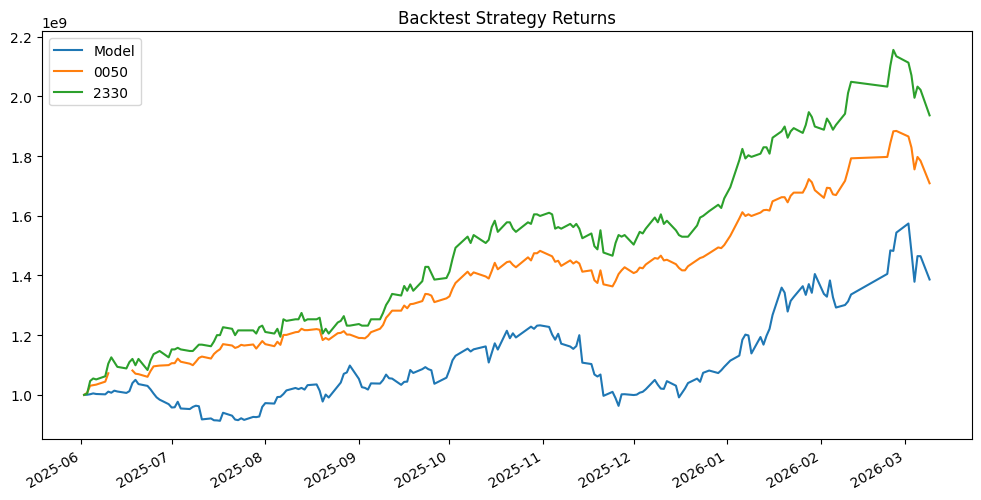

In [9]:
print("Sharpe(0050) Ratio:", etf_sharpe)
returns = {
    "Model": result["model"].returns,
    "0050": close_df["0050"] / close_df["0050"].iloc[0] * 1e9,
    "2330": close_df["2330"] / close_df["2330"].iloc[0] * 1e9,
}
returns = pd.DataFrame(returns)
returns.plot(title="Backtest Strategy Returns", figsize=(12, 6))
# result["model"].returns.plot(title="Backtest Strategy Returns")

Mean Invest Ratio: 0.8627027565588544


<Axes: title={'center': 'Backtest Strategy Invest Ratio'}>

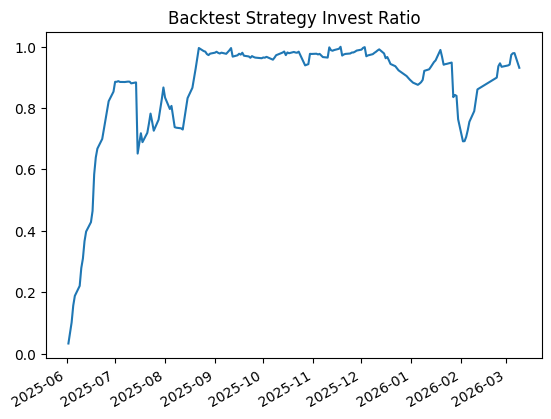

In [10]:
print("Mean Invest Ratio:", result["model"].invest_ratio.mean())
result["model"].invest_ratio.plot(title="Backtest Strategy Invest Ratio")

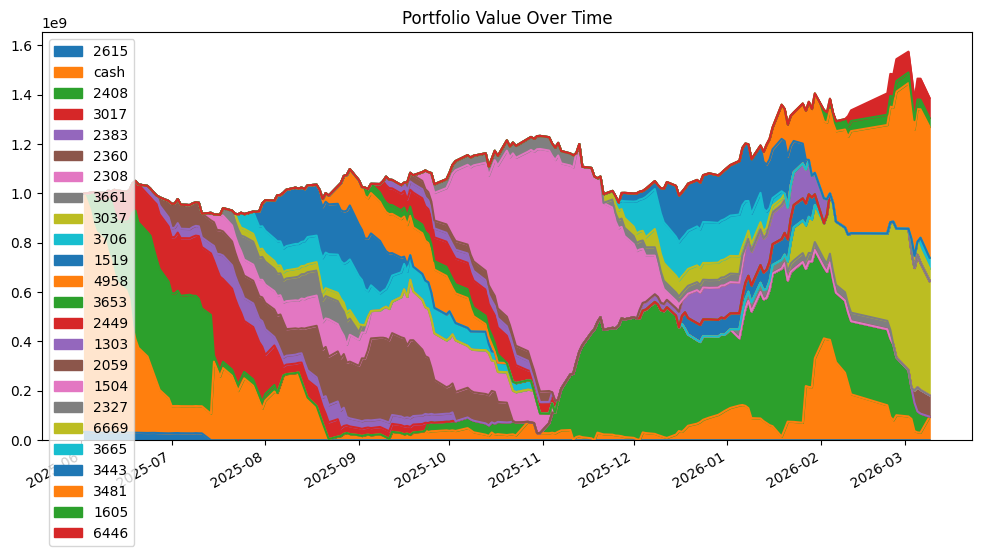

In [11]:
portfolio_value = result["model"].portfolio_value.fillna(0)
portfolio_value.plot(title="Portfolio Value Over Time", figsize=(12, 6), stacked=True, kind='area')
plt.legend(loc='upper left')

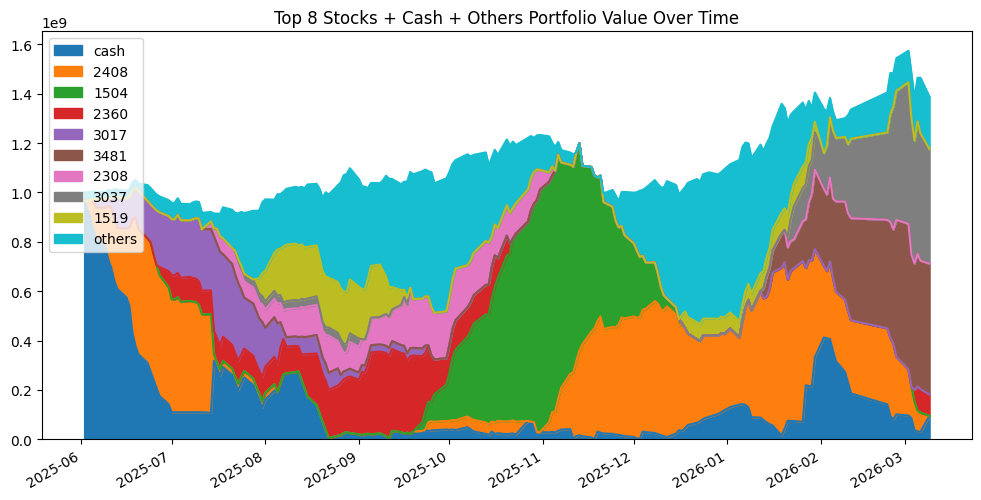

In [12]:
top_n = 8
top_stocks = (
    portfolio_value.drop(columns=["cash"])
    .sum()
    .sort_values(ascending=False)
    .head(top_n)
    .index
)

simplified_portfolio_value = portfolio_value[["cash"]]
simplified_portfolio_value[top_stocks] = portfolio_value[top_stocks]
simplified_portfolio_value["others"] = portfolio_value.drop(
    columns=top_stocks.tolist() + ["cash"]
).sum(axis=1)

simplified_portfolio_value.plot(
    title=f"Top {top_n} Stocks + Cash + Others Portfolio Value Over Time",
    figsize=(12, 6),
    stacked=True,
    kind="area",
    legend=True,
)
plt.legend(loc="upper left")